<a href="https://colab.research.google.com/github/NinhHTK/Fresh-Food-Stockout-Forecasting/blob/main/DataProcess%20%26%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tập dữ liệu của dự án này chỉ lấy dữ liệu của thành phố có ID 03 từ tập dữ liệu train 4.5M rows. Vì dữ liệu tổng quá lớn nên chỉ thực hiện ở 1 quy mô dữ liệu nhỏ hơn.

**PHASE 1 (DATA INGESTION & OVERVIEW)**

In [93]:
from datasets import load_dataset
import pandas as pd

# 1. Tải dataset
print("Đang tải dữ liệu về máy...")
dataset = load_dataset("Dingdong-Inc/FreshRetailNet-50K", split='train')
# 2. Lọc dữ liệu bằng bộ lọc của dataset
print("Đang lọc City ID 3...")
df_city_3 = dataset.filter(lambda example: example['city_id'] == 3)
print(f"Đã hoàn thành! Có {len(df_city_3)} dòng dữ liệu cho City ID 3.")

Đang tải dữ liệu về máy...
Đang lọc City ID 3...
Đã hoàn thành! Có 238320 dòng dữ liệu cho City ID 3.


Overview

In [94]:
# Convert to Pandas DataFrame for data processing
print("\nConverting to Pandas DataFrame...")
df_city_3 = df_city_3.to_pandas()

# Check size and preview data
print(f"Dataset size: {df_city_3.shape}")
df_city_3.head()


Converting to Pandas DataFrame...
Dataset size: (238320, 19)


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,3,70,0,5,6,65,157,2024-03-28,1.80,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7, 1.1, 0.0, ...",15,"[1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, ...",0.914,0,0,0.0142,14.32,31.25,1.57
1,3,70,0,5,6,65,157,2024-03-29,1.50,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, ...",9,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...",0.897,0,0,0.4079,14.60,29.95,1.57
2,3,70,0,5,6,65,157,2024-03-30,1.80,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 0.0, 0.6, ...",11,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",0.897,1,0,0.6128,14.68,31.86,1.34
3,3,70,0,5,6,65,157,2024-03-31,1.78,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6, 0.0, ...",3,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.903,1,0,0.3063,16.94,35.42,1.38
4,3,70,0,5,6,65,157,2024-04-01,1.80,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.0, ...",9,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...",0.897,0,0,0.7007,16.21,39.26,1.23


**PHASE 2 (DATA SELECTION & CLEANING)**

Loại bỏ city_id column

In [95]:
columns_to_drop = ['city_id']
df_city_3 = df_city_3.drop(columns=columns_to_drop, errors='ignore')
print(f"Dropped columns: {columns_to_drop}")
print(f"New DataFrame shape: {df_city_3.shape}")

Dropped columns: ['city_id']
New DataFrame shape: (238320, 18)


Data Validation


In [96]:
import numpy as np

print("Checking for Missing Values:")
missing_values = df_city_3.isnull().sum()
missing_percentage = (df_city_3.isnull().sum() / len(df_city_3)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
print(missing_df[missing_df['Missing Count'] > 0])
if missing_df[missing_df['Missing Count'] > 0].empty:
    print("No missing values found.\n")
else:
    print("\nColumns with missing values found. Consider imputation or removal.\n")

print("Checking for Duplicate Rows:")
list_cols = [col for col in df_city_3.columns if isinstance(df_city_3[col].iloc[0], (list, tuple, np.ndarray))]
subset_cols_for_duplicate_check = [col for col in df_city_3.columns if col not in list_cols]
duplicate_rows = df_city_3.duplicated(subset=subset_cols_for_duplicate_check).sum()
if duplicate_rows == 0:
    print("No duplicate rows found (excluding list/array-type columns).\n")
else:
    print(f"Found {duplicate_rows} duplicate rows (excluding list/array-type columns). Consider removing them.\n")

print("Checking Data Types and Info:")
df_city_3.info()

Checking for Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []
No missing values found.

Checking for Duplicate Rows:
No duplicate rows found (excluding list/array-type columns).

Checking Data Types and Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238320 entries, 0 to 238319
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   store_id             238320 non-null  int64  
 1   management_group_id  238320 non-null  int64  
 2   first_category_id    238320 non-null  int64  
 3   second_category_id   238320 non-null  int64  
 4   third_category_id    238320 non-null  int64  
 5   product_id           238320 non-null  int64  
 6   dt                   238320 non-null  object 
 7   sale_amount          238320 non-null  float64
 8   hours_sale           238320 non-null  object 
 9   stock_hour6_22_cnt   238320 non-null  int32  
 10  hours_stock_status   2383

**PHASE 3 (EDA)**

Cell 1: Setup & Import

In [97]:
import pandas as pd
import numpy as np
from IPython.display import display
# Make a copy to avoid modifying the original DataFrame
df_eda = df_city_3.copy()
print("Đã sao chép dữ liệu sang df_eda.")

Đã sao chép dữ liệu sang df_eda.


Cell 2: Data Type Conversion and Feature Engineering

In [98]:
# Convert 'dt' to datetime if it's not already
if 'dt' in df_eda.columns and not pd.api.types.is_datetime64_any_dtype(df_eda['dt']):
    try:
        df_eda['dt'] = pd.to_datetime(df_eda['dt'])
        df_eda['dt_year'] = df_eda['dt'].dt.year
        df_eda['dt_month'] = df_eda['dt'].dt.month
        df_eda['dt_day'] = df_eda['dt'].dt.day
        df_eda['dt_day_of_week'] = df_eda['dt'].dt.dayofweek
        df_eda['dt_week_of_year'] = df_eda['dt'].dt.isocalendar().week.astype(int)
        print("Converted 'dt' and extracted features.")
    except Exception as e:
        print(f"Could not convert 'dt': {e}")
elif 'dt' in df_eda.columns:
    df_eda['dt_year'] = df_eda['dt'].dt.year
    df_eda['dt_month'] = df_eda['dt'].dt.month
    df_eda['dt_day'] = df_eda['dt'].dt.day
    df_eda['dt_day_of_week'] = df_eda['dt'].dt.dayofweek
    df_eda['dt_week_of_year'] = df_eda['dt'].dt.isocalendar().week.astype(int)
    print("Features already extracted.")

Converted 'dt' and extracted features.


Cell 3: Numerical Statistics

In [99]:
true_numerical_cols = ['sale_amount', 'stock_hour6_22_cnt', 'discount', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level']
categorical_as_numerical_cols = ['holiday_flag', 'activity_flag']

print("1. Descriptive Statistics for Numerical Columns (including binary flags):")

# Get all relevant columns that are present in df_eda
numerical_for_describe_unsorted = [col for col in true_numerical_cols + categorical_as_numerical_cols if col in df_eda.columns]

# Sort these columns based on their original order in df_eda
df_eda_cols_order = list(df_eda.columns)
numerical_for_describe = sorted(
    numerical_for_describe_unsorted,
    key=lambda x: df_eda_cols_order.index(x)
)

display(df_eda[numerical_for_describe].describe())

1. Descriptive Statistics for Numerical Columns (including binary flags):


,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
count,238320.000000,238320.000000,238320.000000,238320.000000,238320.000000,238320.000000,238320.000000,238320.000000,238320.000000
mean,0.679249,3.609617,0.915436,0.344444,0.337240,0.999300,22.610451,40.609608,1.494202
std,0.607614,5.491875,0.122586,0.475188,0.472769,0.744355,4.091855,6.047448,0.236554
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.760000,27.350000,1.020000
25%,0.300000,0.000000,0.847000,0.000000,0.000000,0.526000,19.300000,36.100000,1.340000
50%,0.600000,0.000000,1.000000,0.000000,0.000000,0.835400,22.640000,40.310000,1.460000
75%,0.900000,6.000000,1.000000,1.000000,1.000000,1.290100,26.120000,44.440000,1.600000
max,10.000000,16.000000,1.000000,1.000000,1.000000,6.146300,30.010000,63.340000,3.010000


Cell 4: Categorical Statistics

In [100]:
categorical_id_cols = ['store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id']
categorical_as_numerical_cols = ['holiday_flag', 'activity_flag']

print("2. Descriptive Statistics for Categorical ID and Flag Columns:")
categorical_for_describe = [col for col in categorical_id_cols + categorical_as_numerical_cols if col in df_eda.columns]
df_eda_categorical_subset = df_eda[categorical_for_describe].copy()
for col in categorical_for_describe:
    df_eda_categorical_subset[col] = df_eda_categorical_subset[col].astype('category')
display(df_eda_categorical_subset.describe())

2. Descriptive Statistics for Categorical ID and Flag Columns:


,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,holiday_flag,activity_flag
count,238320,238320,238320,238320,238320,238320,238320,238320
unique,101,7,23,43,96,173,2,2
top,429,6,4,50,154,834,0,0
freq,5940,126810,43290,25470,16290,9090,156232,157949


Cell 5: Date Analysis

In [101]:
# Danh sách tất cả các cột cần đếm chi tiết từ cả Cell 5 và Cell 7 cũ
all_features_to_vc = [
    'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id',
    'holiday_flag', 'activity_flag',
    'dt_year', 'dt_month', 'dt_day', 'dt_day_of_week', 'dt_week_of_year'
]

print("--- 4. DETAILED VALUE COUNTS (All Features) ---")
for col in all_features_to_vc:
    if col in df_eda.columns:
        unique_count = df_eda[col].nunique()
        print(f"\n--- '{col}' ({unique_count} unique) ---")
        if unique_count <= 10:
            display(df_eda[col].value_counts().sort_index())
        else:
            display(df_eda[col].value_counts().head(10))
            print(f"... (đang hiển thị Top 10 của {unique_count} giá trị)")

--- 4. DETAILED VALUE COUNTS (All Features) ---

--- 'store_id' (101 unique) ---


,count
store_id,
429,5940
837,5760
113,5040
756,4950
317,4680
709,4590
712,4500
784,4320
813,4320


... (đang hiển thị Top 10 của 101 giá trị)

--- 'management_group_id' (7 unique) ---


,count
management_group_id,
0,39060
1,3150
2,19440
3,5040
4,1710
5,43110
6,126810



--- 'first_category_id' (23 unique) ---


...

... (đang hiển thị Top 10 của 31 giá trị)

--- 'dt_day_of_week' (7 unique) ---


,count
dt_day_of_week,
0,34424
1,34424
2,31776
3,34424
4,34424
5,34424
6,34424



--- 'dt_week_of_year' (14 unique) ---


,count
dt_week_of_year,
14,18536
15,18536
17,18536
16,18536
18,18536
19,18536
23,18536
20,18536
21,18536


... (đang hiển thị Top 10 của 14 giá trị)


Cell 6: Array-like Columns Analysis

In [102]:
array_like_cols = ['hours_sale', 'hours_stock_status']
print("4. Analysis of Array-like Columns:")
for col in array_like_cols:
    if col in df_eda.columns:
        print(f"Column '{col}':")
        # Convert to string, replace newline characters, then get value counts
        display(df_eda[col].astype(str).str.replace('\n', '').value_counts().head(5))

4. Analysis of Array-like Columns:
Column 'hours_sale':


,count
hours_sale,
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.],26396
[0. 0. 0. 0. 0. 0. 0. 0. 0.1 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ],1064
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.1 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ],980
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.1 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ],832
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.1 0. 0. 0. 0. 0. 0. 0. ],799


Column 'hours_stock_status':


,count
hours_stock_status,
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],103786
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1],23081
[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],13721
[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],6171
[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0],4491


Cell 7: Detailed Value Counts

In [103]:
all_categorical_for_vc = ['store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id'] + ['holiday_flag', 'activity_flag'] + ['dt_year', 'dt_month', 'dt_day', 'dt_day_of_week', 'dt_week_of_year']

print("5. Detailed Value Counts:")
for col in all_categorical_for_vc:
    if col in df_eda.columns:
        unique_count = df_eda[col].nunique()
        print(f"Unique values in '{col}' ({unique_count} unique):")
        if unique_count <= 10:
            display(df_eda[col].value_counts().sort_index())
        else:
            display(df_eda[col].value_counts().head(10))

5. Detailed Value Counts:
Unique values in 'store_id' (101 unique):


,count
store_id,
429,5940
837,5760
113,5040
756,4950
317,4680
709,4590
712,4500
784,4320
813,4320


Unique values in 'management_group_id' (7 unique):


,count
management_group_id,
0,39060
1,3150
2,19440
3,5040
4,1710
5,43110
6,126810


Unique values in 'first_category_id' (23 unique):


...

,count
dt_day,
28,7944
29,7944
30,7944
1,7944
2,7944
3,7944
4,7944
8,7944
5,7944


Unique values in 'dt_day_of_week' (7 unique):


,count
dt_day_of_week,
0,34424
1,34424
2,31776
3,34424
4,34424
5,34424
6,34424


Unique values in 'dt_week_of_year' (14 unique):


,count
dt_week_of_year,
14,18536
15,18536
17,18536
16,18536
18,18536
19,18536
23,18536
20,18536
21,18536


PHASE 4 (VISUALIZATION)

1 biến

/tmp/ipykernel_15847/3885757169.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='management_group_id', data=df_eda, ax=axes[1, 1],


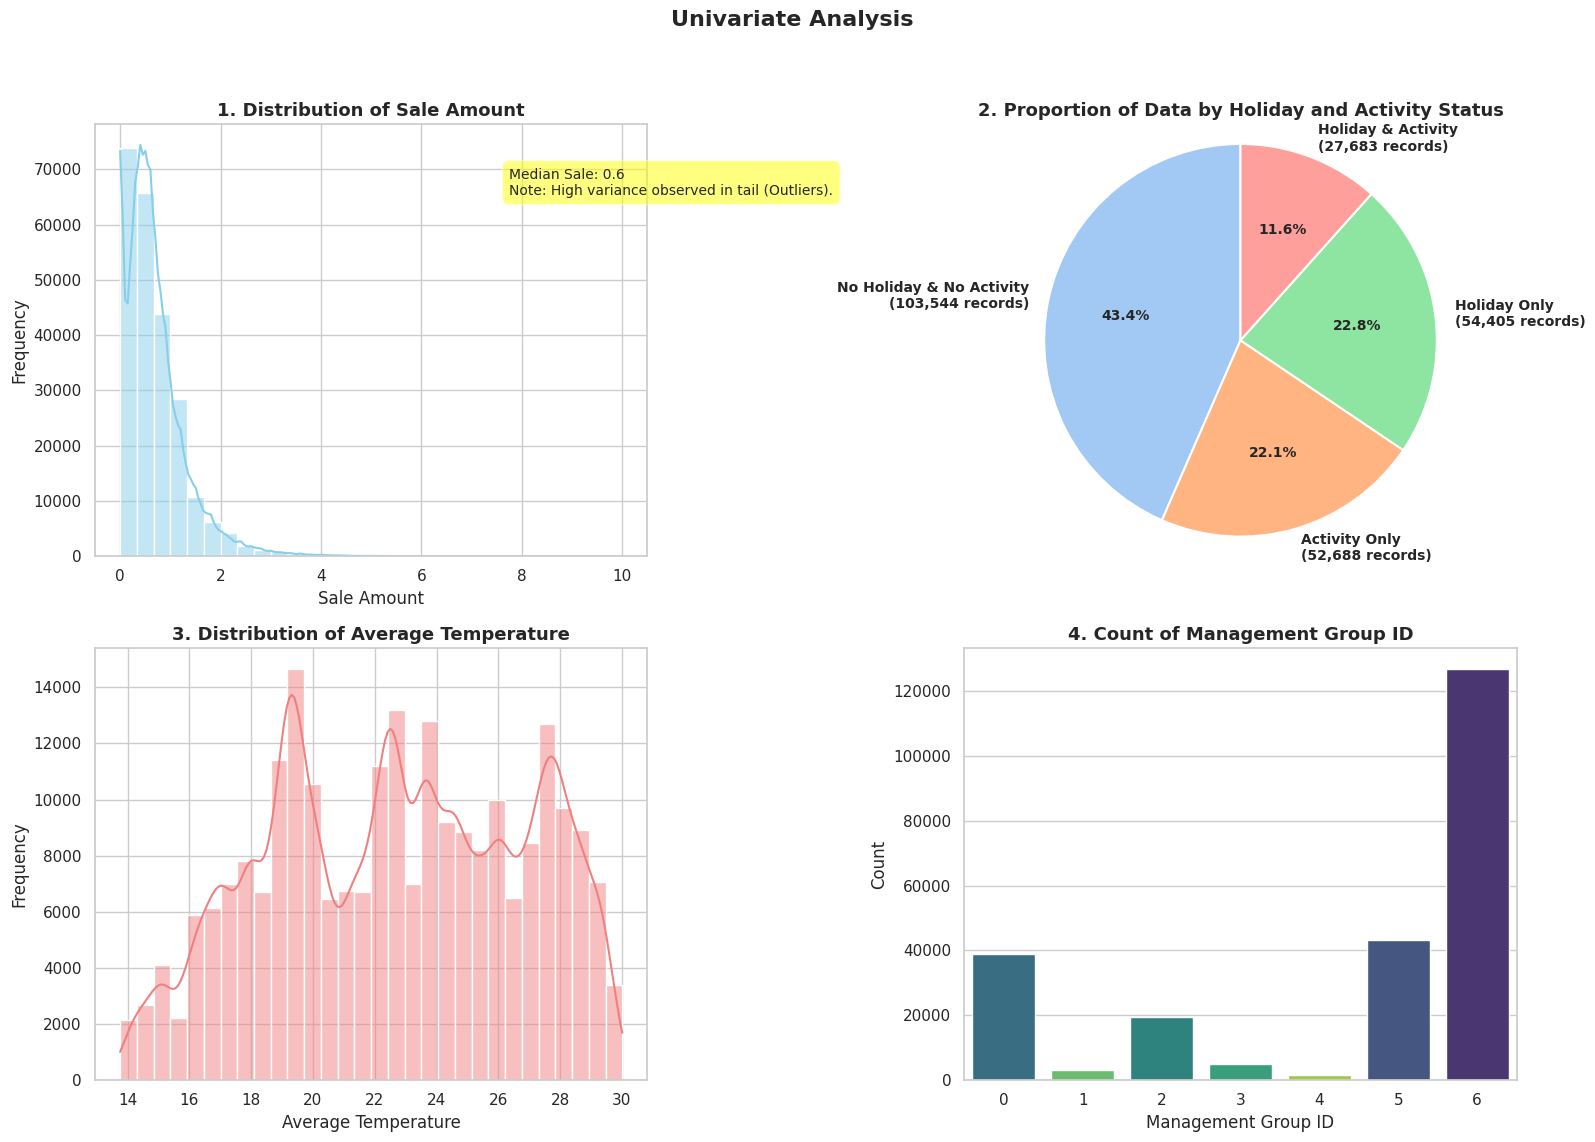

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Univariate Analysis', fontsize=16, fontweight='bold')

# Plot 1: Distribution of Sale Amount
if 'sale_amount' in df_eda.columns:
    sns.histplot(df_eda['sale_amount'], kde=True, ax=axes[0, 0], bins=30, color='skyblue')
    axes[0, 0].set_title('1. Distribution of Sale Amount', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Sale Amount')
    axes[0, 0].set_ylabel('Frequency')
    median_sale = df_eda['sale_amount'].median()
    axes[0, 0].text(0.75, 0.9, f'Median Sale: {median_sale:.1f}\nNote: High variance observed in tail (Outliers).',
                    transform=axes[0, 0].transAxes, fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))
else:
    axes[0, 0].text(0.5, 0.5, 'sale_amount not found', ha='center', va='center')
    axes[0, 0].set_axis_off()

# Plot 2: Pie Chart of Holiday and Activity Flag Contribution
if {'holiday_flag', 'activity_flag'}.issubset(df_eda.columns):
    crosstab_data = pd.crosstab(df_eda['holiday_flag'], df_eda['activity_flag'], dropna=False)
    crosstab_data = crosstab_data.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    pie_data = pd.Series({
        'Holiday & Activity': crosstab_data.loc[1, 1],
        'Holiday Only': crosstab_data.loc[1, 0],
        'Activity Only': crosstab_data.loc[0, 1],
        'No Holiday & No Activity': crosstab_data.loc[0, 0]
    })
    ordered_labels = [
        'No Holiday & No Activity',
        'Activity Only',
        'Holiday Only',
        'Holiday & Activity'
    ]
    pie_data = pie_data.reindex(ordered_labels)
    colors = sns.color_palette('pastel', len(pie_data))
    axes[0, 1].pie(
        pie_data.values,
        labels=[f'{label}\n({val:,} records)' for label, val in pie_data.items()],
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        textprops={'fontsize': 10, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    axes[0, 1].set_title('2. Proportion of Data by Holiday and Activity Status', fontsize=13, fontweight='bold')
    axes[0, 1].axis('equal')
else:
    axes[0, 1].text(0.5, 0.5, 'holiday_flag/activity_flag not found', ha='center', va='center')
    axes[0, 1].set_axis_off()

# Plot 3: Distribution of Average Temperature
if 'avg_temperature' in df_eda.columns:
    sns.histplot(df_eda['avg_temperature'], kde=True, ax=axes[1, 0], bins=30, color='lightcoral')
    axes[1, 0].set_title('3. Distribution of Average Temperature', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Average Temperature')
    axes[1, 0].set_ylabel('Frequency')
else:
    axes[1, 0].text(0.5, 0.5, 'avg_temperature not found', ha='center', va='center')
    axes[1, 0].set_axis_off()

# Plot 4: Count of Management Group ID
if 'management_group_id' in df_eda.columns:
    mg_id_counts = df_eda['management_group_id'].value_counts()
    mg_id_order_ascending = sorted(df_eda['management_group_id'].unique())
    palette = sns.color_palette("viridis", n_colors=len(mg_id_order_ascending))
    mg_id_sorted_by_count_desc = mg_id_counts.sort_values(ascending=False).index.tolist()
    color_map_by_count = {id_val: palette[i] for i, id_val in enumerate(mg_id_sorted_by_count_desc)}
    colors_for_ascending_order = [color_map_by_count[x] for x in mg_id_order_ascending]

    sns.countplot(x='management_group_id', data=df_eda, ax=axes[1, 1],
                  order=mg_id_order_ascending,
                  palette=colors_for_ascending_order)
    axes[1, 1].set_title('4. Count of Management Group ID', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Management Group ID')
    axes[1, 1].set_ylabel('Count')
else:
    axes[1, 1].text(0.5, 0.5, 'management_group_id not found', ha='center', va='center')
    axes[1, 1].set_axis_off()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


2 biến

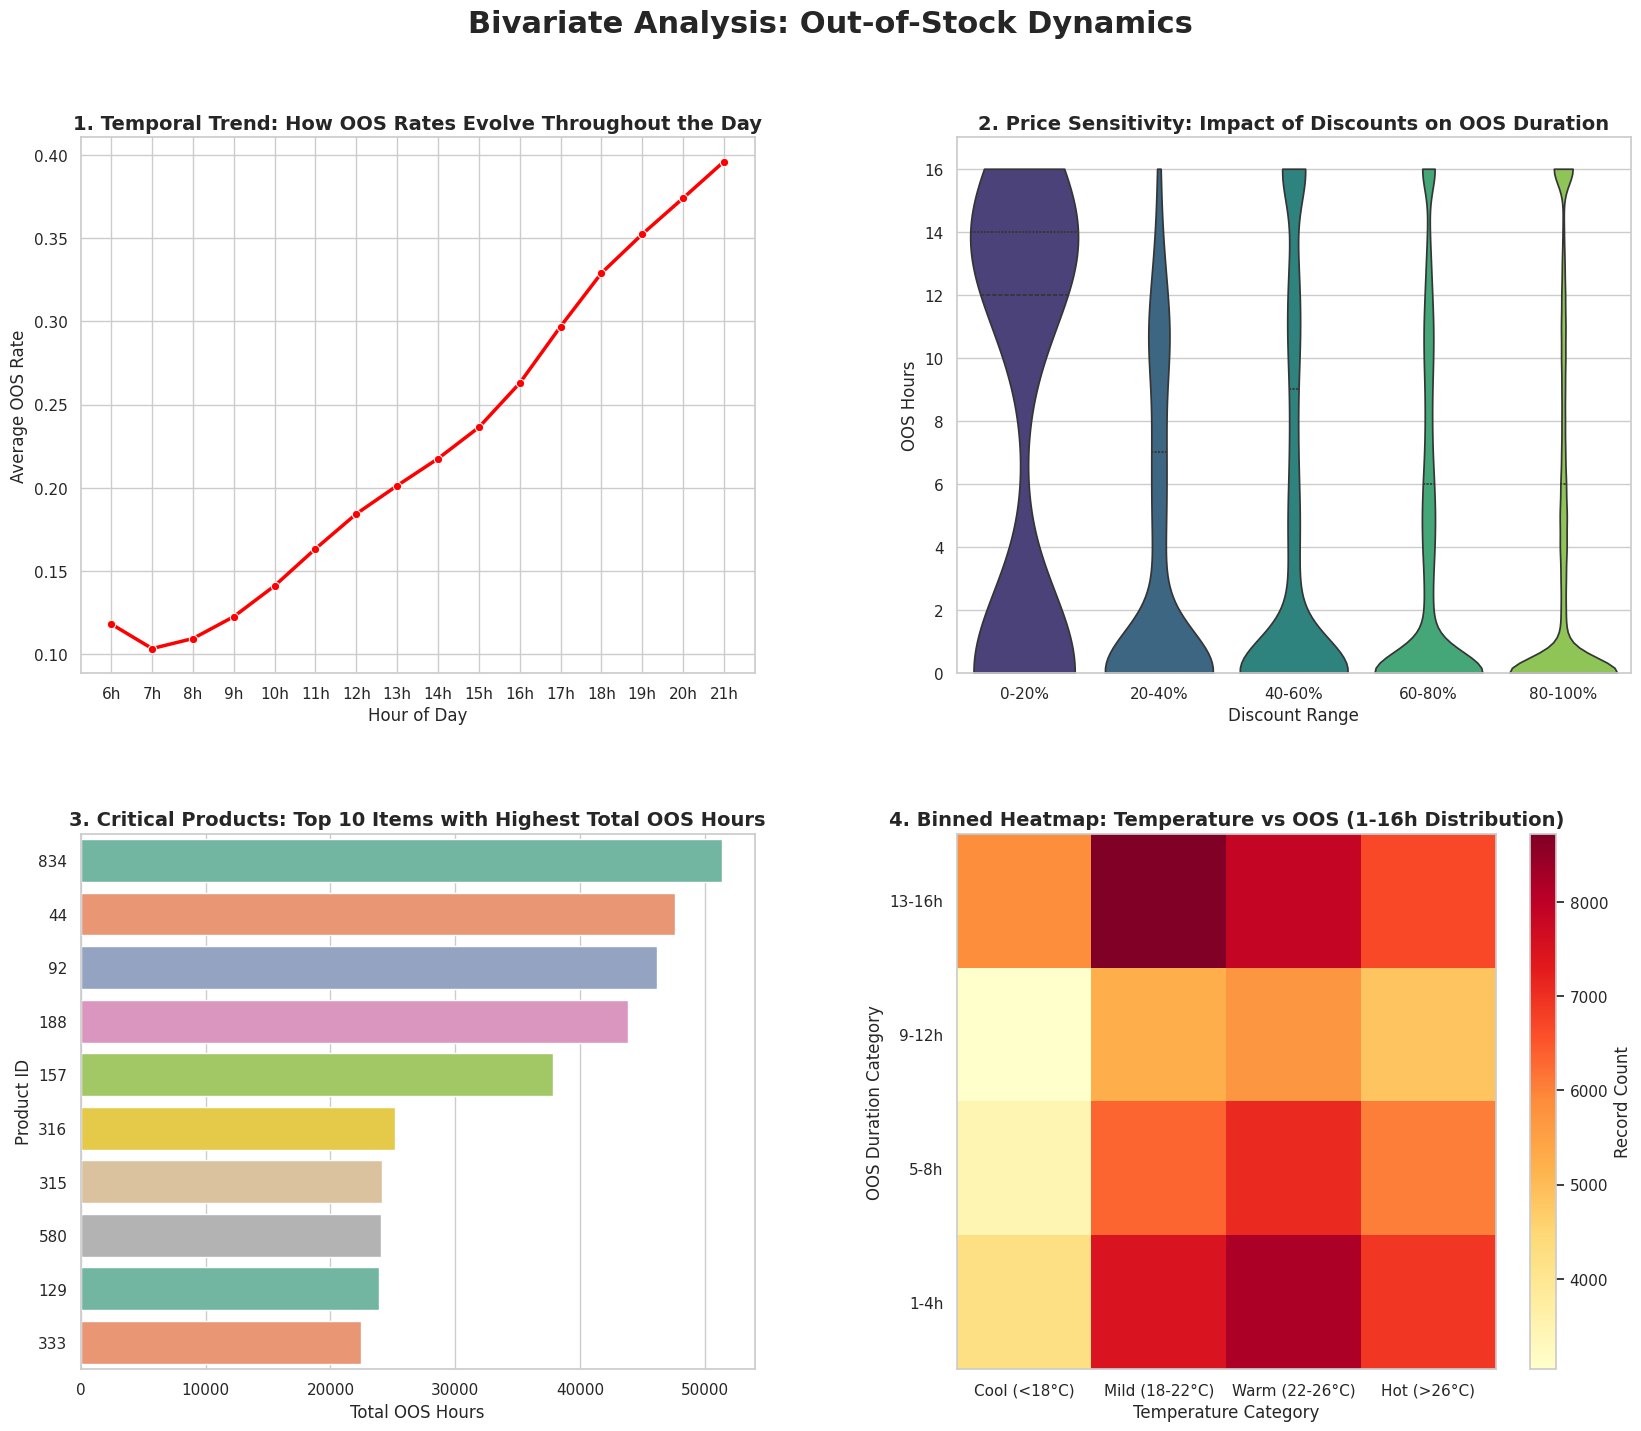

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from matplotlib.gridspec import GridSpec

df = df_eda.copy()

if not pd.api.types.is_datetime64_any_dtype(df['dt']):
    df['dt'] = pd.to_datetime(df['dt'])

def safe_eval(x):
    if isinstance(x, (list, np.ndarray)): return x
    try: return ast.literal_eval(x)
    except: return [0]*24

df['hours_stock_status'] = df['hours_stock_status'].apply(safe_eval)
df['stock_hour6_21_cnt'] = df['hours_stock_status'].apply(lambda x: sum(1 for status in x[6:22] if status == 0))
total_hours_window = 16
hours_df = pd.DataFrame(df['hours_stock_status'].tolist(), columns=[f'{i}h' for i in range(24)])
df['oos_hours_per_record'] = total_hours_window - df['stock_hour6_21_cnt']

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)
fig.suptitle('Bivariate Analysis: Out-of-Stock Dynamics', fontsize=22, fontweight='bold', y=0.96)

ax1 = fig.add_subplot(gs[0, 0])
hourly_oos_rate = hours_df[[f'{i}h' for i in range(6, 22)]].mean()
sns.lineplot(x=hourly_oos_rate.index, y=hourly_oos_rate.values, marker='o', color='red', linewidth=2.5, ax=ax1)
ax1.set_title('1. Temporal Trend: How OOS Rates Evolve Throughout the Day', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Average OOS Rate')

ax2 = fig.add_subplot(gs[0, 1])
df['discount_grp_5'] = pd.cut(df['discount'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])
sns.violinplot(x='discount_grp_5', y='oos_hours_per_record', data=df[df['discount'] <= 1.0], palette='viridis', ax=ax2, hue='discount_grp_5', legend=False, inner="quart", cut=0)
ax2.set_ylim(0, 17)
ax2.set_title('2. Price Sensitivity: Impact of Discounts on OOS Duration', fontsize=14, fontweight='bold')
ax2.set_xlabel('Discount Range')
ax2.set_ylabel('OOS Hours')

ax3 = fig.add_subplot(gs[1, 0])
top_10 = df.groupby('product_id')['oos_hours_per_record'].sum().nlargest(10).reset_index()
top_10['product_id'] = top_10['product_id'].astype(str)
sns.barplot(x='oos_hours_per_record', y='product_id', data=top_10, palette='Set2', hue='product_id', legend=False, ax=ax3)
ax3.set_title('3. Critical Products: Top 10 Items with Highest Total OOS Hours', fontsize=14, fontweight='bold')
ax3.set_xlabel('Total OOS Hours')
ax3.set_ylabel('Product ID')

ax4 = fig.add_subplot(gs[1, 1])
df_oos_only = df[df['oos_hours_per_record'] > 0].copy()
temp_bins_even = [0, 18, 22, 26, 100]
df_oos_only['temp_bins'] = pd.cut(df_oos_only['avg_temperature'], bins=temp_bins_even, labels=[0, 1, 2, 3])

def map_oos_to_4_groups(val):
    if 1 <= val <= 4: return 0.5
    if 5 <= val <= 8: return 1.5
    if 9 <= val <= 12: return 2.5
    return 3.5

df_oos_only['oos_y_coord'] = df_oos_only['oos_hours_per_record'].apply(map_oos_to_4_groups)

h2d = ax4.hist2d(df_oos_only['temp_bins'].astype(float) + 0.5, df_oos_only['oos_y_coord'], bins=[[0, 1, 2, 3, 4], [0, 1, 2, 3, 4]], cmap='YlOrRd')
fig.colorbar(h2d[3], ax=ax4, label='Record Count')

ax4.set_title('4. Binned Heatmap: Temperature vs OOS (1-16h Distribution)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Temperature Category')
ax4.set_ylabel('OOS Duration Category')

temp_labels = ['Cool (<18°C)', 'Mild (18-22°C)', 'Warm (22-26°C)', 'Hot (>26°C)']
ax4.set_xticks([0.5, 1.5, 2.5, 3.5])
ax4.set_xticklabels(temp_labels)

oos_labels = ['1-4h', '5-8h', '9-12h', '13-16h']
ax4.set_yticks([0.5, 1.5, 2.5, 3.5])
ax4.set_yticklabels(oos_labels)

plt.show()

đa biến

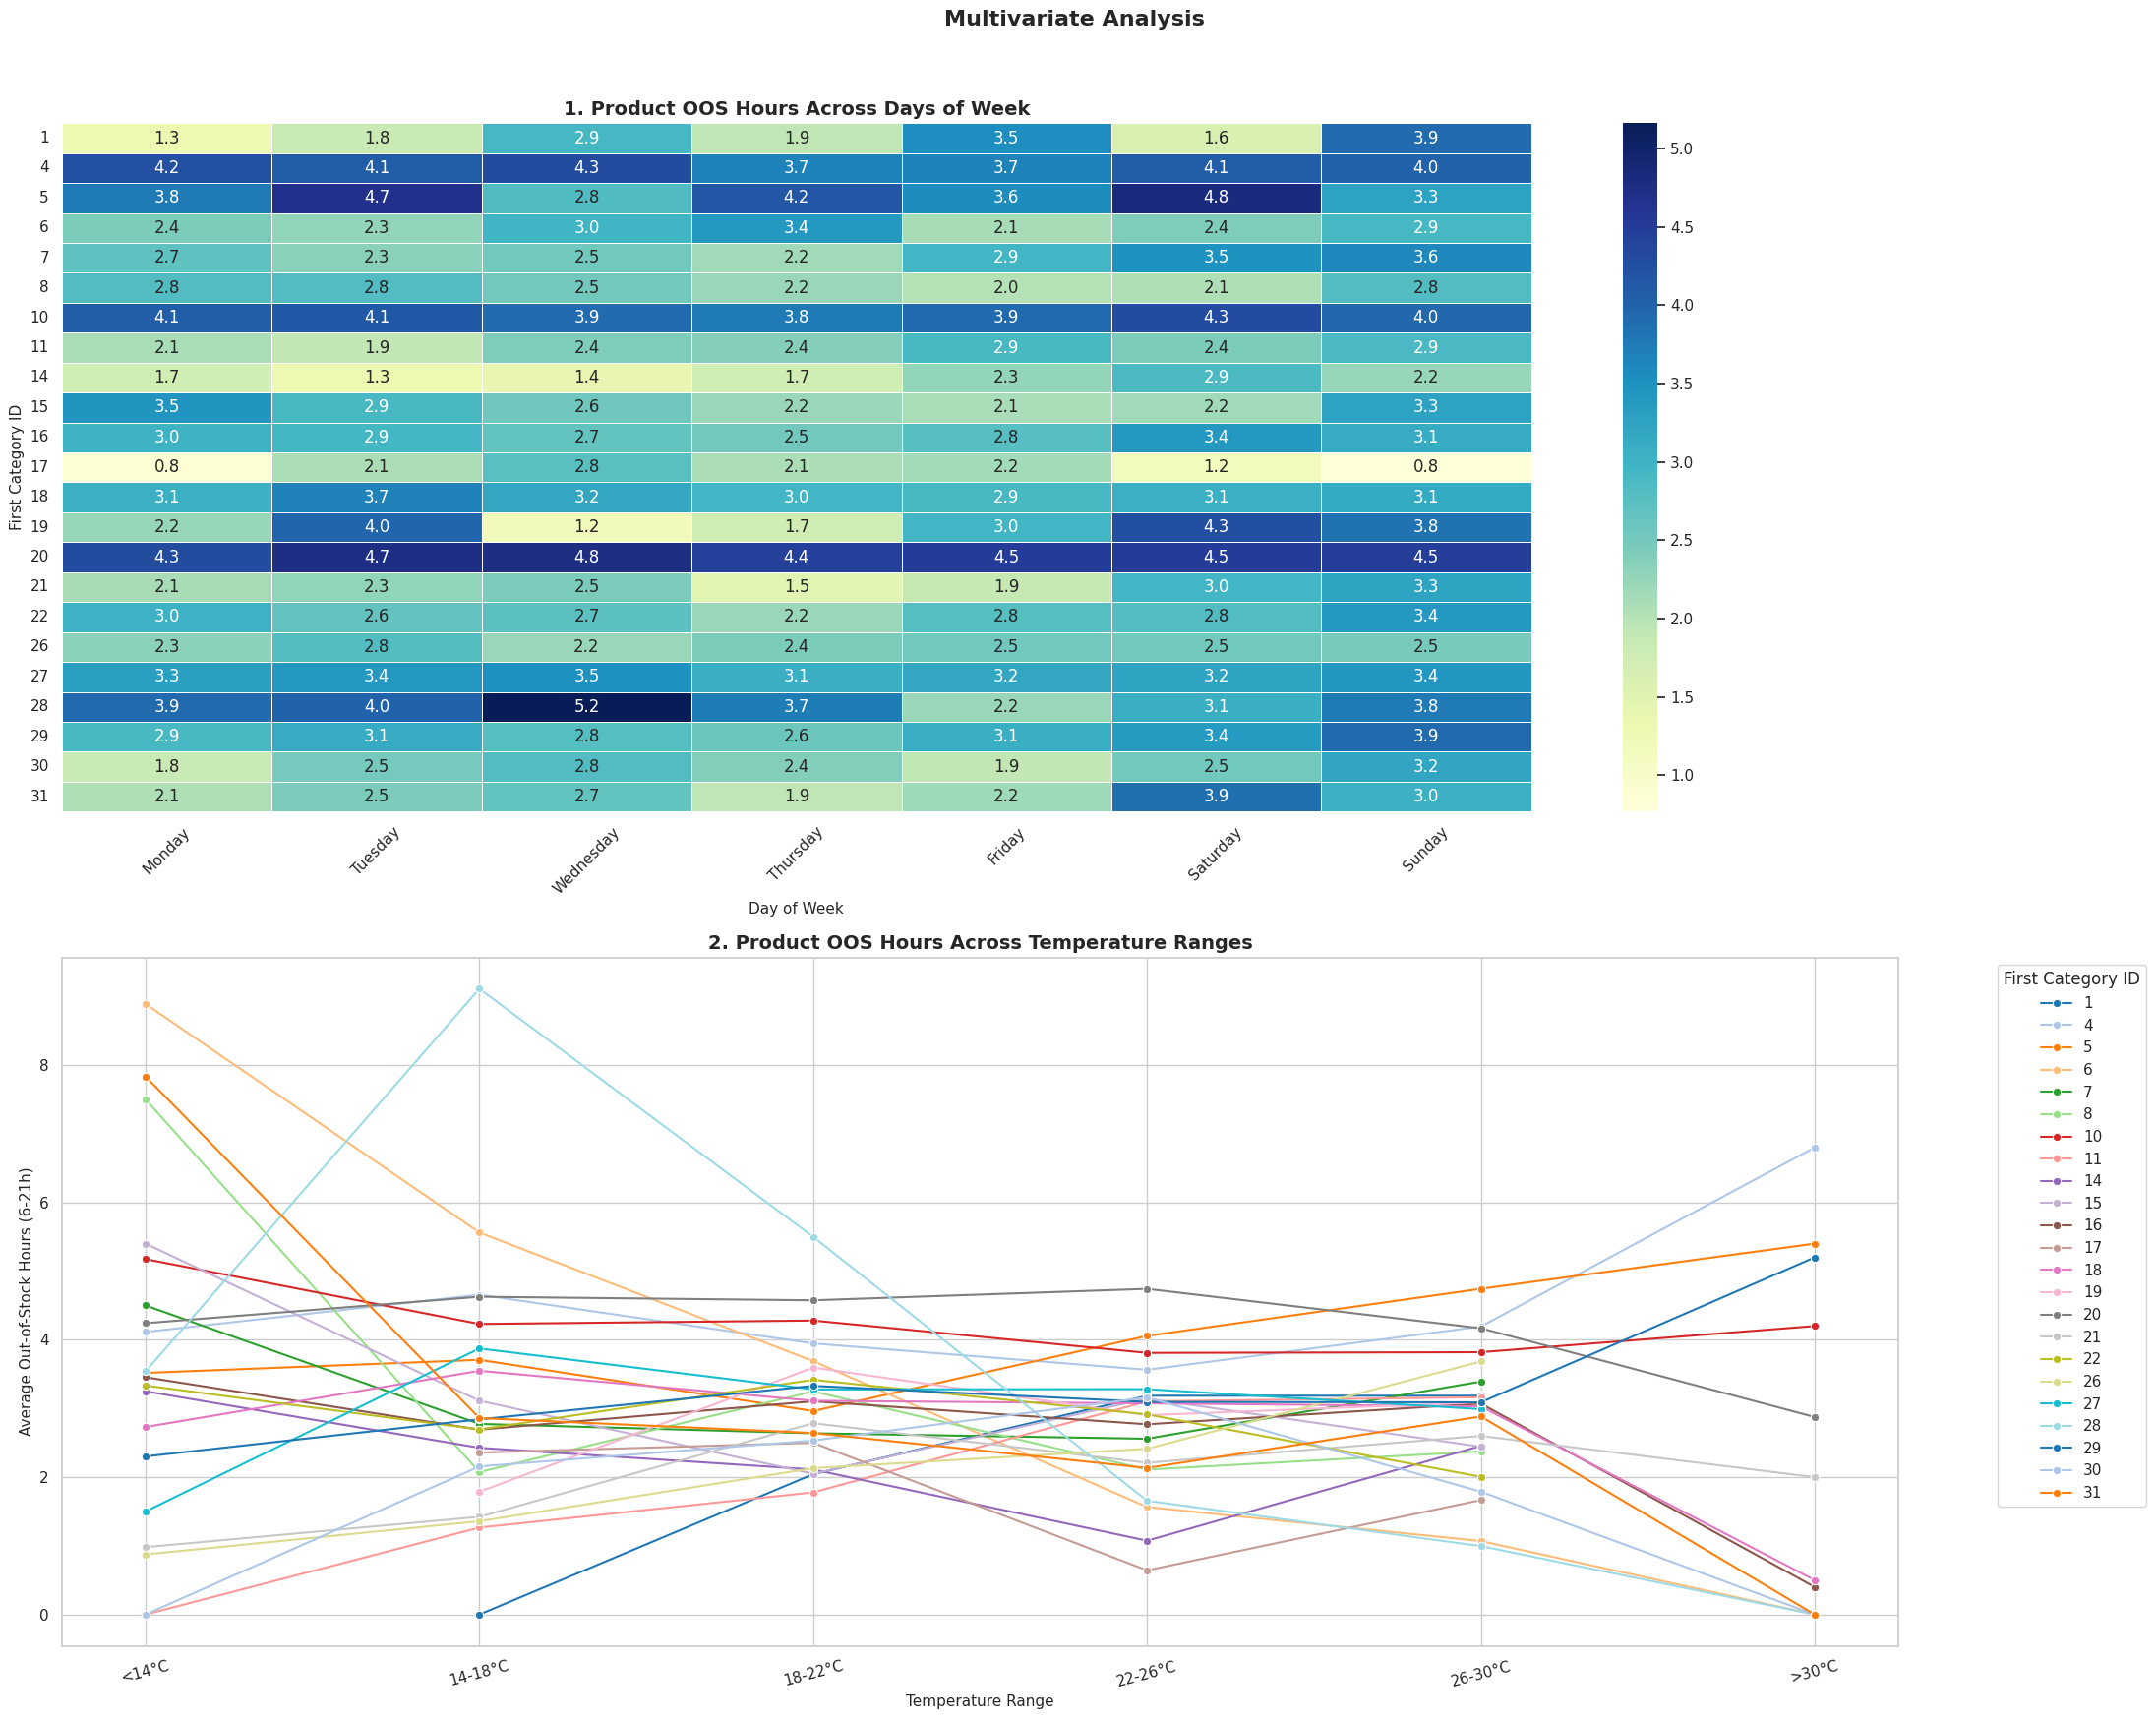

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

fig_multi, axes_multi = plt.subplots(2, 1, figsize=(22, 18))
fig_multi.suptitle('Multivariate Analysis', fontsize=16, fontweight='bold', y=1.00)

if 'dt' in df.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df['day_of_week'] = df['dt'].dt.day_name()
    df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

avg_oos_cat_day = df.groupby(['first_category_id', 'day_of_week'], observed=False)['oos_hours_per_record'].mean().unstack()

sns.heatmap(
    avg_oos_cat_day,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=.5,
    ax=axes_multi[0]
)
axes_multi[0].set_title('1. Product OOS Hours Across Days of Week', fontsize=14, fontweight='bold')
axes_multi[0].set_xlabel('Day of Week', fontsize=11)
axes_multi[0].set_ylabel('First Category ID', fontsize=11)
axes_multi[0].tick_params(axis='x', rotation=45)
axes_multi[0].tick_params(axis='y', rotation=0)

if 'temperature_range' not in df.columns:
    temperature_bins = [0, 14, 18, 22, 26, 30, np.inf]
    temperature_labels = ['<14°C', '14-18°C', '18-22°C', '22-26°C', '26-30°C', '>30°C']
    df['temperature_range'] = pd.cut(df['avg_temperature'], bins=temperature_bins, labels=temperature_labels, right=False)

avg_oos_temp_cat = df.groupby(['temperature_range', 'first_category_id'], observed=False)['oos_hours_per_record'].mean().reset_index()
avg_oos_temp_cat['first_category_id'] = avg_oos_temp_cat['first_category_id'].astype(str)

sns.lineplot(
    x='temperature_range',
    y='oos_hours_per_record',
    hue='first_category_id',
    data=avg_oos_temp_cat,
    marker='o',
    ax=axes_multi[1],
    palette='tab20'
)
axes_multi[1].set_title('2. Product OOS Hours Across Temperature Ranges', fontsize=14, fontweight='bold')
axes_multi[1].set_xlabel('Temperature Range', fontsize=11)
axes_multi[1].set_ylabel('Average Out-of-Stock Hours (6-21h)', fontsize=11)
axes_multi[1].tick_params(axis='x', rotation=15)
axes_multi[1].legend(title='First Category ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

PHASE 5 (FEATURE ENGINEERING)

In [114]:
import pandas as pd
import numpy as np

df_city_3_final = df_city_3.copy()

if 'dt' in df_city_3_final.columns and not pd.api.types.is_datetime64_any_dtype(df_city_3_final['dt']):
    df_city_3_final['dt'] = pd.to_datetime(df_city_3_final['dt'])
    print("Converted 'dt' column in df_city_3_final to datetime type for consistency.")
elif 'dt' in df_city_3_final.columns:
    print("'dt' column in df_city_3_final is already datetime.")
else:
    print("'dt' column not found in df_city_3_final (skipping conversion).")

# --- Feature 1: Lagged Out-of-stock Rate (oos_rate_lag1_day) ---

if 'oos_hours_per_record' in df.columns and 'dt' in df.columns and 'total_hours_in_window_new' in globals() and total_hours_in_window_new > 0:

    df_temp_for_lag = df.copy()

    df_temp_for_lag = df_temp_for_lag.sort_values(by=['store_id', 'product_id', 'dt'])

    df_temp_for_lag['oos_rate_daily'] = df_temp_for_lag['oos_hours_per_record'] / total_hours_in_window_new

    df_temp_for_lag['oos_rate_lag1_day_calculated'] = df_temp_for_lag.groupby(['store_id', 'product_id'])['oos_rate_daily'].shift(1)

    df_temp_for_lag['oos_rate_lag1_day_calculated'] = df_temp_for_lag['oos_rate_lag1_day_calculated'].fillna(0)

    df_temp_for_lag['merge_key'] = df_temp_for_lag['store_id'].astype(str) + '_' + df_temp_for_lag['product_id'].astype(str) + '_' + df_temp_for_lag['dt'].dt.strftime('%Y%m%d')

    df_city_3_final['merge_key'] = df_city_3_final['store_id'].astype(str) + '_' + df_city_3_final['product_id'].astype(str) + '_' + df_city_3_final['dt'].dt.strftime('%Y%m%d')

    oos_rate_map = df_temp_for_lag.set_index('merge_key')['oos_rate_lag1_day_calculated']
    df_city_3_final['oos_rate_lag1_day'] = df_city_3_final['merge_key'].map(oos_rate_map)

    df_city_3_final = df_city_3_final.drop(columns=['merge_key'])

    df_city_3_final['oos_rate_lag1_day'] = df_city_3_final['oos_rate_lag1_day'].fillna(0)

    print(f"Added 'oos_rate_lag1_day' feature to 'df_city_3_final'. Min: {df_city_3_final['oos_rate_lag1_day'].min():.2f}, Max: {df_city_3_final['oos_rate_lag1_day'].max():.2f}\n")
else:
    print("Could not add 'oos_rate_lag1_day'. Required columns or 'total_hours_in_window_new' not found/invalid.\n")

# --- Feature 2: Is Weekend (binary flag) ---

if 'dt' in df_city_3_final.columns and pd.api.types.is_datetime64_any_dtype(df_city_3_final['dt']):

    df_city_3_final['is_weekend'] = df_city_3_final['dt'].dt.dayofweek.isin([5, 6]).astype(int)
    print(f"Added 'is_weekend' feature to 'df_city_3_final'. Weekend count: {df_city_3_final['is_weekend'].sum()}, Weekday count: {(~df_city_3_final['is_weekend'].astype(bool)).sum()}\n")
else:
    print("Could not add 'is_weekend'. 'dt' column in df_city_3_final is not datetime type or not present.\n")

print("Feature engineering complete. The new DataFrame with features is 'df_city_3_final'.")

Converted 'dt' column in df_city_3_final to datetime type for consistency.
Added 'oos_rate_lag1_day' feature to 'df_city_3_final'. Min: 0.00, Max: 1.00

Added 'is_weekend' feature to 'df_city_3_final'. Weekend count: 68848, Weekday count: 169472

Feature engineering complete. The new DataFrame with features is 'df_city_3_final'.


Create file

In [115]:
import numpy as np
import pandas as pd # Ensure pandas is imported if not already

output_filename = "freshretailnet_city03_dataset.csv"

df_city_3_for_export = df_city_3_final.copy()

for col in ['hours_sale', 'hours_stock_status']:
    if col in df_city_3_for_export.columns and df_city_3_for_export[col].apply(lambda x: isinstance(x, np.ndarray)).any():
        df_city_3_for_export[col] = df_city_3_for_export[col].apply(lambda x: str(x.tolist()))

df_city_3_for_export.to_csv(output_filename, index=False)
print(f"DataFrame saved to {output_filename}")

DataFrame saved to freshretailnet_city03_dataset.csv


END